# simple_bias_correction 官方数据验证

## 验证目标

将迁移后的两个插件方法与 IMPROVER 原实现进行逐点对比：

| 插件 | 功能 |
|------|------|
| `CalculateForecastBias` | 由历史预报与实况计算偏差场（forecast − truth 的时间均值） |
| `ApplyBiasCorrection` | 用偏差场对预报施加加性订正（forecast − bias） |

## 对照方式

每个场景对照三条结果：

1. **修改后方法** — 读预处理后的 meb 六维 `.nc`，调用迁移插件
2. **原方法** — 读官方投影/经纬 Cube，调用 IMPROVER 同名插件
3. **KGO** — 官方已知正确输出

## 验证范围

- **Section 3**：投影坐标输入，各场景直接数值对比
- **Section 4**：经纬重网格输入，插值后对比（容差放宽）
- **Section 5**：CLI 端到端（含写出/读回），验证完整业务链路

## 1. 环境准备


In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import xarray as xr
from iris.cube import CubeList

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"
DATA_DIR = PACKAGE_ROOT / "test_data"

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

from improver.calibration.simple_bias_correction import (  # noqa: E402
    ApplyBiasCorrection as OrigApplyBiasCorrection,
    CalculateForecastBias as OrigCalculateForecastBias,
)
from improver.utilities.cube_manipulation import MergeCubes  # noqa: E402

from simple_bias_correction.src.simple_bias_correction import (  # noqa: E402
    ApplyBiasCorrection,
    CalculateForecastBias,
)


D:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. 辅助函数定义

In [2]:
def require_files(paths, label: str) -> None:
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少{label}（共 {len(missing)} 个）。",
            "请先运行: python simple_bias_correction/cli/preprocess_test_data.py\n",
            + "\n".join(missing[:8])
        )


def list_period_files(directory: Path, period_token: str) -> list[Path]:
    # 按文件名中的 PT 标记筛选（如 PT0003H00M / PT0000H00M）
    return sorted(Path(directory).glob(f"*{period_token}*.nc"))


def spatial_values(data) -> np.ndarray:
    # Cube / DataArray / ndarray -> ndarray（masked->NaN），再 squeeze
    if isinstance(data, xr.DataArray):
        arr = np.asarray(data.values, dtype=np.float64)
    elif hasattr(data, "data"):
        raw = data.data
        arr = (
            np.ma.filled(np.ma.asarray(raw, dtype=np.float64), np.nan)
            if np.ma.isMaskedArray(raw)
            else np.asarray(raw, dtype=np.float64)
        )
    else:
        arr = np.asarray(data, dtype=np.float64)
    return np.squeeze(arr)


def compare_fields(current, reference, tag: str, *, rtol: float = 1e-5, atol: float = 1e-4) -> dict:
    # 打印两场差异；返回统计字典
    c = spatial_values(current)
    r = spatial_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"形状不一致: current={c.shape}, reference={r.shape}, tag={tag}")

    both_nan = np.isnan(c) & np.isnan(r)
    finite = np.isfinite(c) & np.isfinite(r)
    only_c = np.isfinite(c) & np.isnan(r)
    only_r = np.isnan(c) & np.isfinite(r)
    diff = np.zeros_like(c, dtype=np.float64)
    diff[finite] = c[finite] - r[finite]

    stats = {
        "allclose": bool(np.allclose(c, r, rtol=rtol, atol=atol, equal_nan=True)),
        "mean_abs": float(np.mean(np.abs(diff[finite]))) if np.any(finite) else 0.0,
        "max_abs": float(np.max(np.abs(diff[finite]))) if np.any(finite) else 0.0,
        "rmse": float(np.sqrt(np.mean(diff[finite] ** 2))) if np.any(finite) else 0.0,
        "nan_mismatch": int(only_c.sum() + only_r.sum()),
        "both_nan": int(both_nan.sum()),
    }
    print(
        f"[{tag}] allclose={stats['allclose']}, "
        f"mean_abs={stats['mean_abs']:.8f}, max_abs={stats['max_abs']:.8f}, "
        f"rmse={stats['rmse']:.8f}, nan_mismatch={stats['nan_mismatch']}"
    )
    return stats


def plot_triplet(
    modified,
    original,
    kgo,
    title: str,
    *,
    member_index: int = 0,
    labels: tuple[str, str, str] | None = None,
) -> None:
    """绘制三幅结果图：修改后、原方法、KGO（不绘制差值）。"""
    if labels is None:
        labels = ("修改后", "原方法", "KGO")
    panels = []
    for field in (modified, original, kgo):
        arr = spatial_values(field)
        if arr.ndim == 3:
            arr = arr[member_index]
        if arr.ndim != 2:
            raise ValueError(f"绘图期望二维，当前 {arr.shape}")
        panels.append(arr)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, name in zip(axes, panels, labels):
        im = ax.imshow(data, origin="lower", cmap="viridis", aspect="auto")
        ax.set_title(name)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


## 3. 投影坐标输入验证

### CalculateForecastBias（偏差计算）

**输入**：历史预报 + 实况各若干个单日文件（沿 `time` 维拼接）
**输出**：空间偏差场 `forecast_error_of_<name>`（多日时为时间平均）

投影对齐输入位于 `cli_input/`（投影维仅重命名为 `lat`/`lon`，数值仍为米制）。修改后读 meb；原方法读官方投影 Cube；KGO 直接比数值。

#### 单日偏差

仅使用 20220811 一天的预报（PT0003H00M）与实况（PT0000H00M），计算单次偏差场。对照 `single_frt/kgo.nc`。

修改后: forecast_error_of_wind_speed ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 122, 142)
原方法: forecast_error_of_wind_speed (122, 142)
time_bounds: None
[CalculateForecastBias 单日 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 单日 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 单日 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


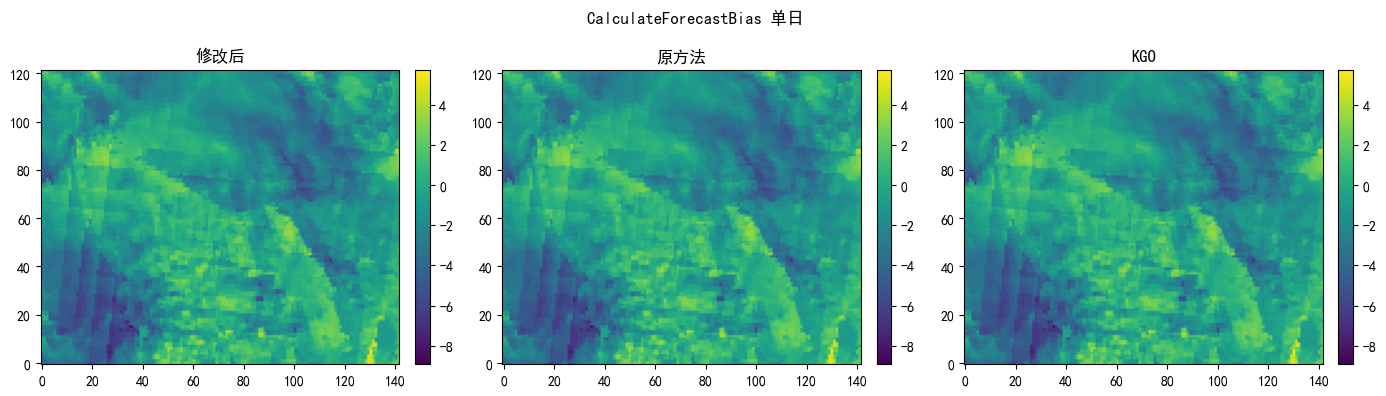

In [3]:
# --- 路径定义 ---
CALC_DIR = DATA_DIR / "calculate-forecast-bias"
CALC_INPUTS = CALC_DIR / "inputs"
CALC_MEB = CALC_INPUTS / "cli_input"  # 投影维重命名后的 meb 版本
SINGLE_DAY = "20220811"

# --- 读取输入 ---
# PT0003H00M = 含 3h 预报时效；PT0000H00M = 分析/实况
fcst_paths = [p for p in list_period_files(CALC_INPUTS, "PT0003H00M") if SINGLE_DAY in p.name]
truth_paths = [p for p in list_period_files(CALC_INPUTS, "PT0000H00M") if SINGLE_DAY in p.name]
fcst_meb_paths = [CALC_MEB / p.name for p in fcst_paths]
truth_meb_paths = [CALC_MEB / p.name for p in truth_paths]
kgo_path = CALC_DIR / "single_frt" / "kgo.nc"
require_files(fcst_paths + truth_paths + fcst_meb_paths + truth_meb_paths + [kgo_path], "单日偏差用例")

# --- 修改后方法：meb 读出 → 沿 time 拼接 → 计算偏差 ---
mod_bias_s1 = CalculateForecastBias().process(
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in fcst_meb_paths
    ], dim="time", coords="different", compat="equals"),
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in truth_meb_paths
    ], dim="time", coords="different", compat="equals"),
)
# --- 原方法：Iris Cube 读出 → MergeCubes → 计算偏差 ---
orig_bias_s1 = OrigCalculateForecastBias().process(
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in fcst_paths])),
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in truth_paths])),
)
kgo_s1 = iris.load_cube(str(kgo_path))

# --- 对比 ---
print("修改后:", mod_bias_s1.name, mod_bias_s1.dims, mod_bias_s1.shape)
print("原方法:", orig_bias_s1.name(), orig_bias_s1.shape)
print("time_bounds:", mod_bias_s1.attrs.get("time_bounds"))

compare_fields(mod_bias_s1, kgo_s1, "CalculateForecastBias 单日 修改后-KGO")
compare_fields(mod_bias_s1, orig_bias_s1, "CalculateForecastBias 单日 修改后-原方法")
compare_fields(orig_bias_s1, kgo_s1, "CalculateForecastBias 单日 原方法-KGO")
plot_triplet(mod_bias_s1, orig_bias_s1, kgo_s1, "CalculateForecastBias 单日")

#### 多日平均偏差

三天历史样本（20220811–13）沿 `time` 拼接后求均值偏差。输出含 `time_bounds` 标记时间跨度。对照 `multiple_frt/kgo.nc`。

修改后 time: ['2022-08-13T00:00:00.000000000'] bounds: [np.str_('2022-08-11T00:00:00.000000000'), np.str_('2022-08-13T00:00:00.000000000')]
原方法 FRT bounds: [[1660176000 1660348800]]
[CalculateForecastBias 多日 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 多日 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 多日 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


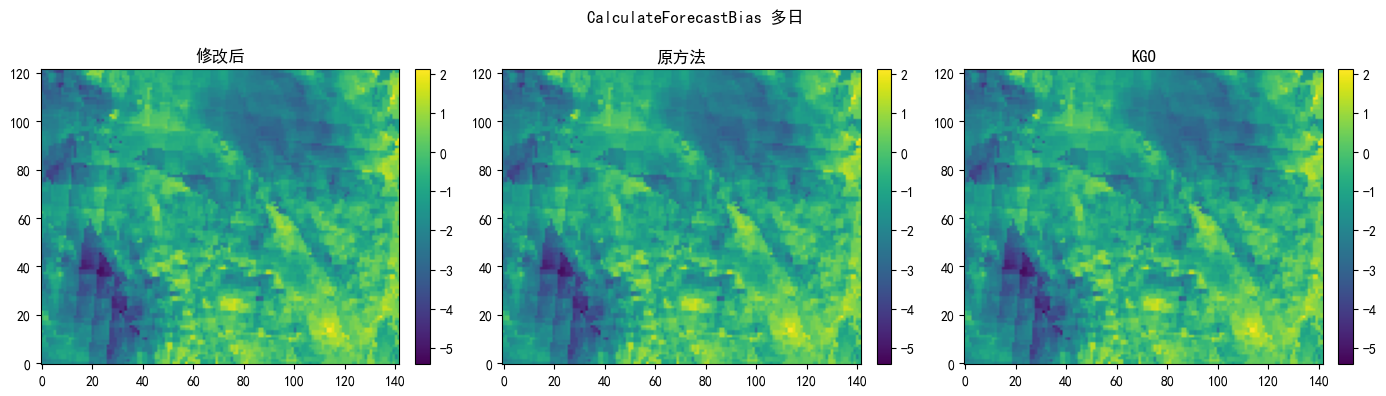

In [4]:
# --- 路径定义 ---
CALC_INPUTS = DATA_DIR / "calculate-forecast-bias" / "inputs"
CALC_MEB = CALC_INPUTS / "cli_input"
MULTI_DAYS = ("20220811", "20220812", "20220813")

# --- 读取输入 ---
fcst_paths = [
    p for p in list_period_files(CALC_INPUTS, "PT0003H00M") if any(d in p.name for d in MULTI_DAYS)
]
truth_paths = [
    p for p in list_period_files(CALC_INPUTS, "PT0000H00M") if any(d in p.name for d in MULTI_DAYS)
]
fcst_meb_paths = [CALC_MEB / p.name for p in fcst_paths]
truth_meb_paths = [CALC_MEB / p.name for p in truth_paths]
kgo_path = DATA_DIR / "calculate-forecast-bias" / "multiple_frt" / "kgo.nc"
require_files(fcst_paths + truth_paths + fcst_meb_paths + truth_meb_paths + [kgo_path], "多日偏差用例")

# --- 修改后方法 ---
mod_bias_m1 = CalculateForecastBias().process(
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in fcst_meb_paths
    ], dim="time", coords="different", compat="equals"),
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in truth_meb_paths
    ], dim="time", coords="different", compat="equals"),
)
# --- 原方法 ---
orig_bias_m1 = OrigCalculateForecastBias().process(
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in fcst_paths])),
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in truth_paths])),
)
kgo_m1 = iris.load_cube(str(kgo_path))

# --- 对比（关注 time_bounds 与 FRT bounds 的一致性）---
print("修改后 time:", mod_bias_m1["time"].values, "bounds:", mod_bias_m1.attrs.get("time_bounds"))
print("原方法 FRT bounds:", orig_bias_m1.coord("forecast_reference_time").bounds)

compare_fields(mod_bias_m1, kgo_m1, "CalculateForecastBias 多日 修改后-KGO")
compare_fields(mod_bias_m1, orig_bias_m1, "CalculateForecastBias 多日 修改后-原方法")
compare_fields(orig_bias_m1, kgo_m1, "CalculateForecastBias 多日 原方法-KGO")
plot_triplet(mod_bias_m1, orig_bias_m1, kgo_m1, "CalculateForecastBias 多日")

#### 掩码多日偏差

输入含 masked/NaN 区域（如海洋格点），验证缺测传播逻辑：两侧任一缺测时结果为 NaN。对照 `multiple_frt_masked_inputs/kgo.nc`。

修改后 nan 比例: 0.1836758254444701
KGO nan/mask 比例: 0.1836758254444701
[CalculateForecastBias 掩码多日 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 掩码多日 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 掩码多日 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


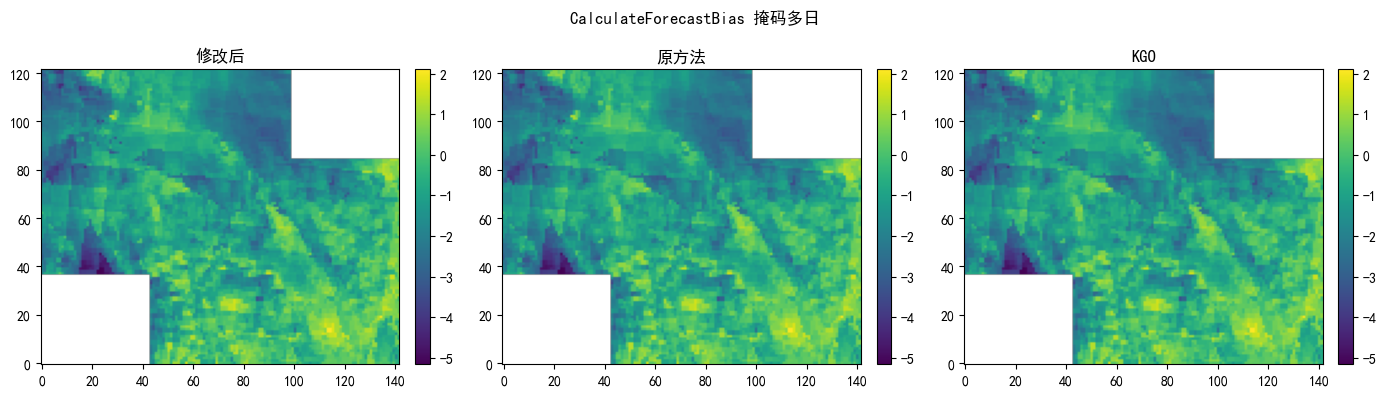

In [5]:
# --- 路径定义 ---
CALC_INPUTS_MASKED = DATA_DIR / "calculate-forecast-bias" / "inputs" / "masked"
CALC_MEB_MASKED = CALC_INPUTS_MASKED / "cli_input"

# --- 读取输入 ---
fcst_paths = list_period_files(CALC_INPUTS_MASKED, "PT0003H00M")
truth_paths = list_period_files(CALC_INPUTS_MASKED, "PT0000H00M")
fcst_meb_paths = [CALC_MEB_MASKED / p.name for p in fcst_paths]
truth_meb_paths = [CALC_MEB_MASKED / p.name for p in truth_paths]
kgo_path = DATA_DIR / "calculate-forecast-bias" / "multiple_frt_masked_inputs" / "kgo.nc"
require_files(fcst_paths + truth_paths + fcst_meb_paths + truth_meb_paths + [kgo_path], "掩码多日偏差用例")

# --- 修改后方法 ---
mod_bias_mask = CalculateForecastBias().process(
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in fcst_meb_paths
    ], dim="time", coords="different", compat="equals"),
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in truth_meb_paths
    ], dim="time", coords="different", compat="equals"),
)
# --- 原方法 ---
orig_bias_mask = OrigCalculateForecastBias().process(
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in fcst_paths])),
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in truth_paths])),
)
kgo_mask = iris.load_cube(str(kgo_path))

# --- 对比（重点验证 NaN 比例一致）---
print("修改后 nan 比例:", float(np.isnan(spatial_values(mod_bias_mask)).mean()))
print("KGO nan/mask 比例:", float(np.isnan(spatial_values(kgo_mask)).mean()))

compare_fields(mod_bias_mask, kgo_mask, "CalculateForecastBias 掩码多日 修改后-KGO")
compare_fields(mod_bias_mask, orig_bias_mask, "CalculateForecastBias 掩码多日 修改后-原方法")
compare_fields(orig_bias_mask, kgo_mask, "CalculateForecastBias 掩码多日 原方法-KGO")
plot_triplet(mod_bias_mask, orig_bias_mask, kgo_mask, "CalculateForecastBias 掩码多日")

### ApplyBiasCorrection（偏差订正）

**输入**：一个当前预报（可含多 member）+ 零个或多个偏差场  
**输出**：订正后预报（forecast − bias），可选下界/上界裁剪  
**核心公式**：`corrected = forecast - bias`（偏差定义为 forecast − truth）

#### 单偏差文件订正

风速订正使用 `lower_bound=0`（防止出现负风速）。偏差来自 `single_bias_file/bias_data/`（含 FRT bounds，代表多日平均结果）。对照 `single_bias_file/kgo.nc`。

修改后: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (5, 1, 1, 1, 41, 48)
[ApplyBiasCorrection 单bias 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[ApplyBiasCorrection 单bias 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[ApplyBiasCorrection 单bias 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


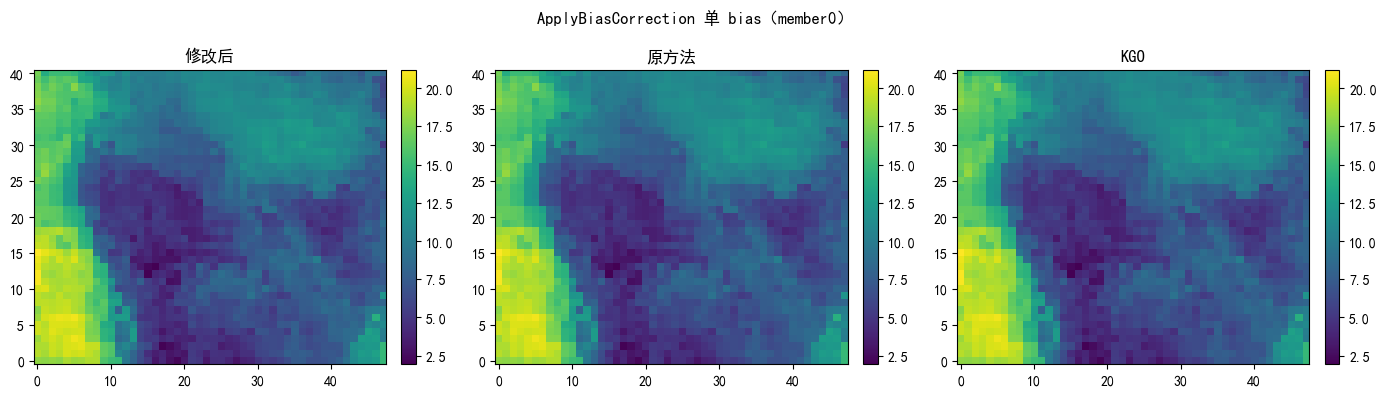

In [6]:
# --- 路径定义 ---
APPLY_DIR = DATA_DIR / "apply-bias-correction"
APPLY_FCST = APPLY_DIR / "20220814T0300Z-PT0003H00M-wind_speed_at_10m.nc"  # 当前预报（含 5 member）
APPLY_MEB_FCST = APPLY_DIR / "cli_input" / APPLY_FCST.name
APPLY_SINGLE = APPLY_DIR / "single_bias_file"

bias_name = "20220813T0300Z-PT0003H00M-wind_speed_at_10m.nc"  # 已算好的平均偏差（含 FRT bounds）
bias_cube_path = APPLY_SINGLE / "bias_data" / bias_name
bias_meb_path = APPLY_SINGLE / "bias_data" / "cli_input" / bias_name
kgo_path = APPLY_SINGLE / "kgo.nc"
require_files([APPLY_FCST, APPLY_MEB_FCST, bias_cube_path, bias_meb_path, kgo_path], "单偏差订正用例")

# --- 修改后方法：读入预报 + 偏差 → 施加订正 ---
mod_corr = ApplyBiasCorrection(lower_bound=0.0).process(
    meb.checkout_griddata(meb.read_griddata_from_nc(str(APPLY_MEB_FCST)), valid_val=(-np.inf, np.inf, np.nan)),
    meb.checkout_griddata(meb.read_griddata_from_nc(str(bias_meb_path)), valid_val=(-np.inf, np.inf, np.nan)),
)
# --- 原方法 ---
orig_corr = OrigApplyBiasCorrection(lower_bound=0.0).process(
    iris.load_cube(str(APPLY_FCST)), iris.load_cube(str(bias_cube_path))
)
kgo_corr = iris.load_cube(str(kgo_path))

# --- 对比 ---
print("修改后:", mod_corr.dims, mod_corr.shape)
compare_fields(mod_corr, kgo_corr, "ApplyBiasCorrection 单bias 修改后-KGO")
compare_fields(mod_corr, orig_corr, "ApplyBiasCorrection 单bias 修改后-原方法")
compare_fields(orig_corr, kgo_corr, "ApplyBiasCorrection 单bias 原方法-KGO")
plot_triplet(mod_corr, orig_corr, kgo_corr, "ApplyBiasCorrection 单 bias（member0）", member_index=0)

#### 多偏差文件取均值

对 `multiple_bias_files/bias_data/` 中三日偏差沿 `time` 求均值后统一订正。对照 `multiple_bias_files/kgo.nc`。

[ApplyBiasCorrection 多bias 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[ApplyBiasCorrection 多bias 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[ApplyBiasCorrection 多bias 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


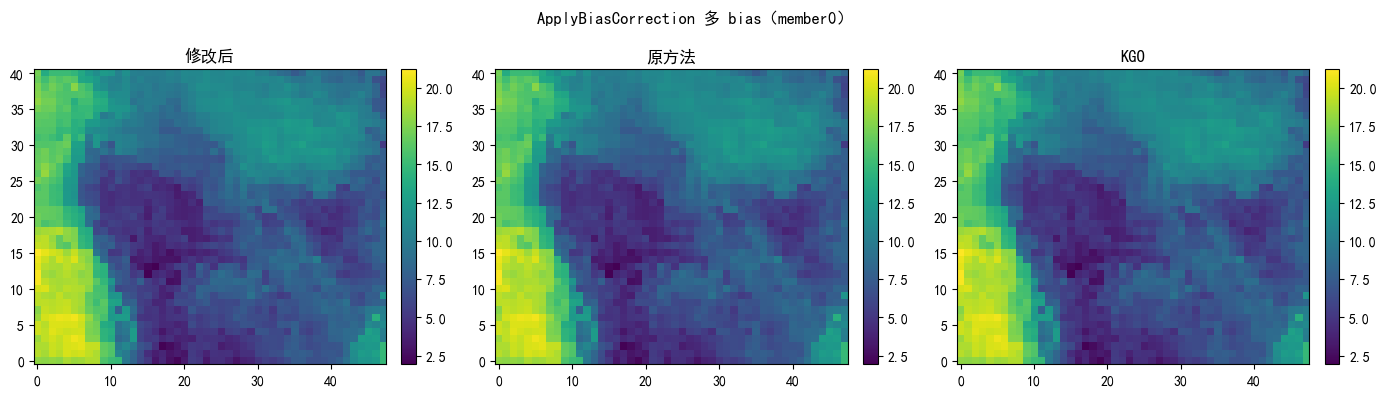

In [7]:
# --- 路径定义 ---
APPLY_DIR = DATA_DIR / "apply-bias-correction"
APPLY_FCST = APPLY_DIR / "20220814T0300Z-PT0003H00M-wind_speed_at_10m.nc"  # 当前预报（含 5 member）
APPLY_MEB_FCST = APPLY_DIR / "cli_input" / APPLY_FCST.name
APPLY_MULTI = APPLY_DIR / "multiple_bias_files"

# --- 读取输入：三日独立偏差文件 ---
bias_cube_paths = sorted((APPLY_MULTI / "bias_data").glob("*.nc"))
bias_meb_paths = [APPLY_MULTI / "bias_data" / "cli_input" / p.name for p in bias_cube_paths]
kgo_path = APPLY_MULTI / "kgo.nc"
require_files([APPLY_FCST, APPLY_MEB_FCST, *bias_cube_paths, *bias_meb_paths, kgo_path], "多偏差订正用例")

# --- 修改后方法：传入预报 + 多个偏差 → 插件内部沿 time 取均值后订正 ---
mod_corr_multi = ApplyBiasCorrection(lower_bound=0.0).process(
    meb.checkout_griddata(meb.read_griddata_from_nc(str(APPLY_MEB_FCST)), valid_val=(-np.inf, np.inf, np.nan)),
    *[meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan)) for p in bias_meb_paths],
)
# --- 原方法 ---
orig_corr_multi = OrigApplyBiasCorrection(lower_bound=0.0).process(
    iris.load_cube(str(APPLY_FCST)), *[iris.load_cube(str(p)) for p in bias_cube_paths]
)
kgo_multi = iris.load_cube(str(kgo_path))

# --- 对比 ---
compare_fields(mod_corr_multi, kgo_multi, "ApplyBiasCorrection 多bias 修改后-KGO")
compare_fields(mod_corr_multi, orig_corr_multi, "ApplyBiasCorrection 多bias 修改后-原方法")
compare_fields(orig_corr_multi, kgo_multi, "ApplyBiasCorrection 多bias 原方法-KGO")
plot_triplet(
    mod_corr_multi, orig_corr_multi, kgo_multi,
    "ApplyBiasCorrection 多 bias（member0）", member_index=0,
)

#### 偏差含缺测（fill / retain）

偏差场部分格点为 NaN，测试两种策略：
- `fill_masked_bias_values=True`：NaN 填 0，该处订正量为 0（预报不变）
- `fill_masked_bias_values=False`：保留 NaN，订正后对应格点仍为 NaN

对照 `fill_masked_values/kgo.nc` 与 `retain_mask/kgo.nc`。

[ApplyBiasCorrection fill 修改后-KGO] allclose=False, mean_abs=0.00023432, max_abs=0.61233664, rmse=0.00895185, nan_mismatch=0
[ApplyBiasCorrection fill 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


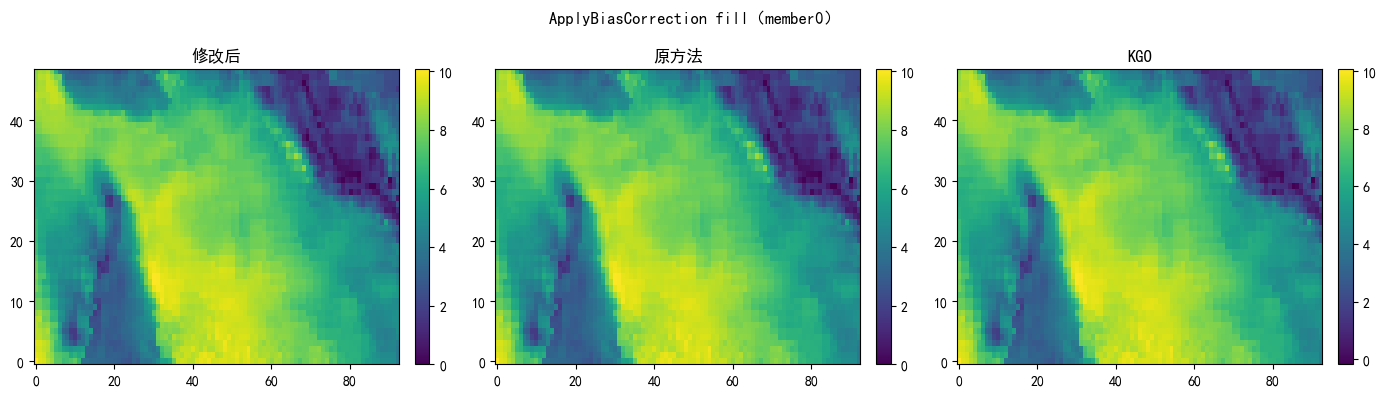

In [8]:
APPLY_MASKED = DATA_DIR / "apply-bias-correction" / "masked_bias_data"

masked_fcst = APPLY_MASKED / "20220814T0300Z-PT0003H00M-wind_speed_at_10m.nc"
masked_fcst_meb = APPLY_MASKED / "cli_input" / masked_fcst.name
masked_bias = APPLY_MASKED / "bias_data" / "20220813T0300Z-PT0003H00M-wind_speed_at_10m.nc"
masked_bias_meb = APPLY_MASKED / "bias_data" / "cli_input" / masked_bias.name
kgo_fill = APPLY_MASKED / "fill_masked_values" / "kgo.nc"
kgo_retain = APPLY_MASKED / "retain_mask" / "kgo.nc"
require_files(
    [masked_fcst, masked_fcst_meb, masked_bias, masked_bias_meb, kgo_fill, kgo_retain],
    "掩码偏差订正用例",
)

# `fill_masked_bias_values=True`：NaN 填 0，该处订正量为 0（预报不变）
# 修改后插件方法调用
mod_fill = ApplyBiasCorrection(lower_bound=0.0, fill_masked_bias_values=True).process(
    meb.checkout_griddata(meb.read_griddata_from_nc(str(masked_fcst_meb)), valid_val=(-np.inf, np.inf, np.nan)),
    meb.checkout_griddata(meb.read_griddata_from_nc(str(masked_bias_meb)), valid_val=(-np.inf, np.inf, np.nan)),
)
# 原方法插件调用
orig_fill = OrigApplyBiasCorrection(lower_bound=0.0, fill_masked_bias_values=True).process(
    iris.load_cube(str(masked_fcst)), iris.load_cube(str(masked_bias))
)
compare_fields(mod_fill, iris.load_cube(str(kgo_fill)), "ApplyBiasCorrection fill 修改后-KGO")
compare_fields(mod_fill, orig_fill, "ApplyBiasCorrection fill 修改后-原方法")
plot_triplet(
    mod_fill, orig_fill, iris.load_cube(str(kgo_fill)),
    "ApplyBiasCorrection fill（member0）", member_index=0,
)


[ApplyBiasCorrection retain 修改后-KGO] allclose=False, mean_abs=0.00023980, max_abs=0.61233664, rmse=0.00905578, nan_mismatch=0
[ApplyBiasCorrection retain 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


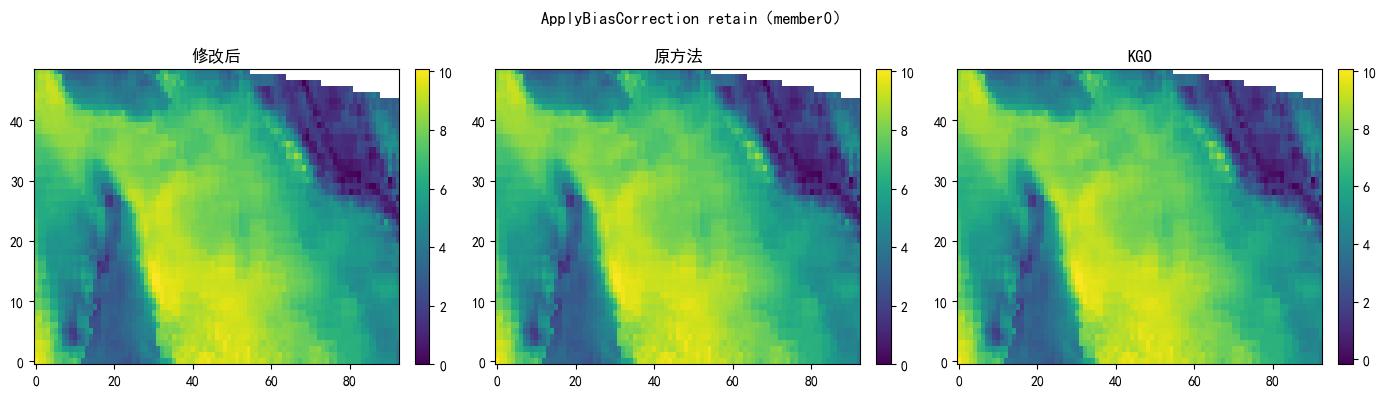

In [9]:
# `fill_masked_bias_values=False`：保留 NaN，订正后对应格点仍为 NaN
# 修改后插件方法调用
mod_retain = ApplyBiasCorrection(lower_bound=0.0, fill_masked_bias_values=False).process(
    meb.checkout_griddata(meb.read_griddata_from_nc(str(masked_fcst_meb)), valid_val=(-np.inf, np.inf, np.nan)),
    meb.checkout_griddata(meb.read_griddata_from_nc(str(masked_bias_meb)), valid_val=(-np.inf, np.inf, np.nan)),
)
# 原方法插件调用
orig_retain = OrigApplyBiasCorrection(lower_bound=0.0, fill_masked_bias_values=False).process(
    iris.load_cube(str(masked_fcst)), iris.load_cube(str(masked_bias))
)
compare_fields(mod_retain, iris.load_cube(str(kgo_retain)), "ApplyBiasCorrection retain 修改后-KGO")
compare_fields(mod_retain, orig_retain, "ApplyBiasCorrection retain 修改后-原方法")
plot_triplet(
    mod_retain, orig_retain, iris.load_cube(str(kgo_retain)),
    "ApplyBiasCorrection retain（member0）", member_index=0,
)

## 4. 经纬重网格输入（`latlon/` + `latlon/cli_input/`）

- **原方法**：读 `latlon/*.nc`（经纬 Cube）
- **修改后**：读 `latlon/cli_input/*.nc`（同源数值的 meb）
- **KGO**：官方仍为投影网格；本 notebook 用同一重网格逻辑把投影 KGO 转到经纬后再比（插值可能引入额外误差）。


### CalculateForecastBias（偏差计算）

#### 多日平均偏差（经纬输入）


经纬网格 lat 范围: -42.576622009277344 -39.92134094238281
[CalculateForecastBias 多日 经纬 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CalculateForecastBias 多日 经纬 修改后-KGO(重网格)] allclose=True, mean_abs=0.00000008, max_abs=0.00000072, rmse=0.00000013, nan_mismatch=0
[CalculateForecastBias 多日 经纬 原方法-KGO(重网格)] allclose=True, mean_abs=0.00000008, max_abs=0.00000072, rmse=0.00000013, nan_mismatch=0


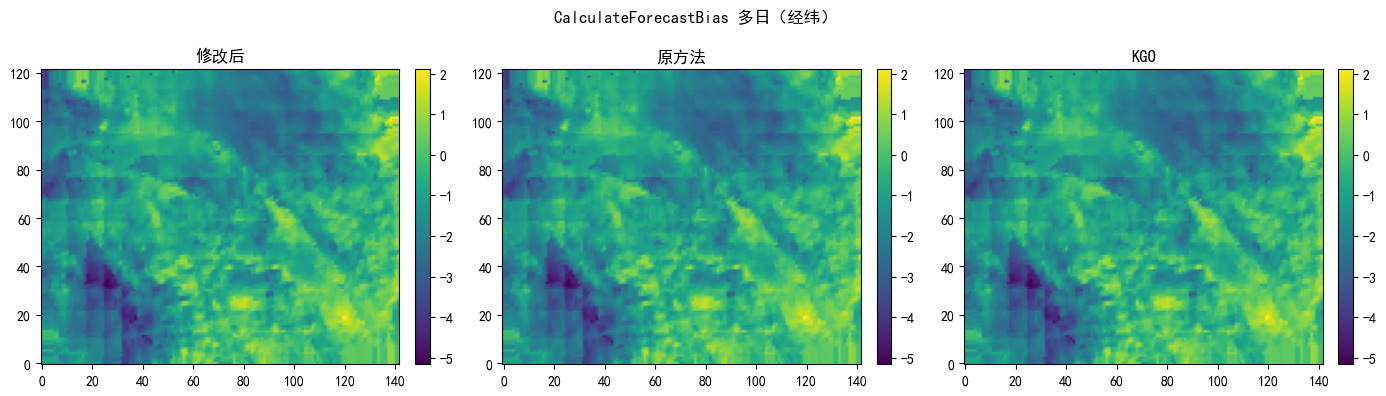

In [10]:
# --- 路径定义 ---
CALC_INPUTS = DATA_DIR / "calculate-forecast-bias" / "inputs"
MULTI_DAYS = ("20220811", "20220812", "20220813")
CALC_LATLON = CALC_INPUTS / "latlon"          # 经纬 Cube（供原方法）
CALC_LATLON_MEB = CALC_LATLON / "cli_input"   # 经纬 meb（供修改后）

# --- 读取输入 ---
fcst_ll = [
    p for p in list_period_files(CALC_LATLON, "PT0003H00M") if any(d in p.name for d in MULTI_DAYS)
]
truth_ll = [
    p for p in list_period_files(CALC_LATLON, "PT0000H00M") if any(d in p.name for d in MULTI_DAYS)
]
fcst_ll_meb = [CALC_LATLON_MEB / p.name for p in fcst_ll]
truth_ll_meb = [CALC_LATLON_MEB / p.name for p in truth_ll]
kgo_proj = DATA_DIR / "calculate-forecast-bias" / "multiple_frt" / "kgo.nc"
require_files(fcst_ll + truth_ll + fcst_ll_meb + truth_ll_meb + [kgo_proj], "经纬多日偏差用例")

# --- 修改后方法 ---
mod_bias_ll = CalculateForecastBias().process(
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in fcst_ll_meb
    ], dim="time", coords="different", compat="equals"),
    xr.concat([
        meb.checkout_griddata(meb.read_griddata_from_nc(str(p)), valid_val=(-np.inf, np.inf, np.nan))
        for p in truth_ll_meb
    ], dim="time", coords="different", compat="equals"),
)
# --- 原方法 ---
orig_bias_ll = OrigCalculateForecastBias().process(
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in fcst_ll])),
    MergeCubes()(CubeList([iris.load_cube(str(p)) for p in truth_ll])),
)
# KGO：由 preprocess 将投影 KGO 重网格到经纬后写出
kgo_ll = iris.load_cube(str(kgo_proj.parent / "latlon" / "kgo.nc"))

# --- 对比（经纬输入有插值误差，容差放宽到 1e-2）---
print("经纬网格 lat 范围:", float(mod_bias_ll.lat.min()), float(mod_bias_ll.lat.max()))
compare_fields(mod_bias_ll, orig_bias_ll, "CalculateForecastBias 多日 经纬 修改后-原方法")
compare_fields(mod_bias_ll, kgo_ll, "CalculateForecastBias 多日 经纬 修改后-KGO(重网格)", atol=1e-2)
compare_fields(orig_bias_ll, kgo_ll, "CalculateForecastBias 多日 经纬 原方法-KGO(重网格)", atol=1e-2)
plot_triplet(mod_bias_ll, orig_bias_ll, kgo_ll, "CalculateForecastBias 多日（经纬）")

### ApplyBiasCorrection（偏差订正）

#### 单偏差订正（经纬输入）


[ApplyBiasCorrection 单bias 经纬 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[ApplyBiasCorrection 单bias 经纬 修改后-KGO(重网格)] allclose=True, mean_abs=0.00000019, max_abs=0.00000191, rmse=0.00000044, nan_mismatch=0
[ApplyBiasCorrection 单bias 经纬 原方法-KGO(重网格)] allclose=True, mean_abs=0.00000019, max_abs=0.00000191, rmse=0.00000044, nan_mismatch=0


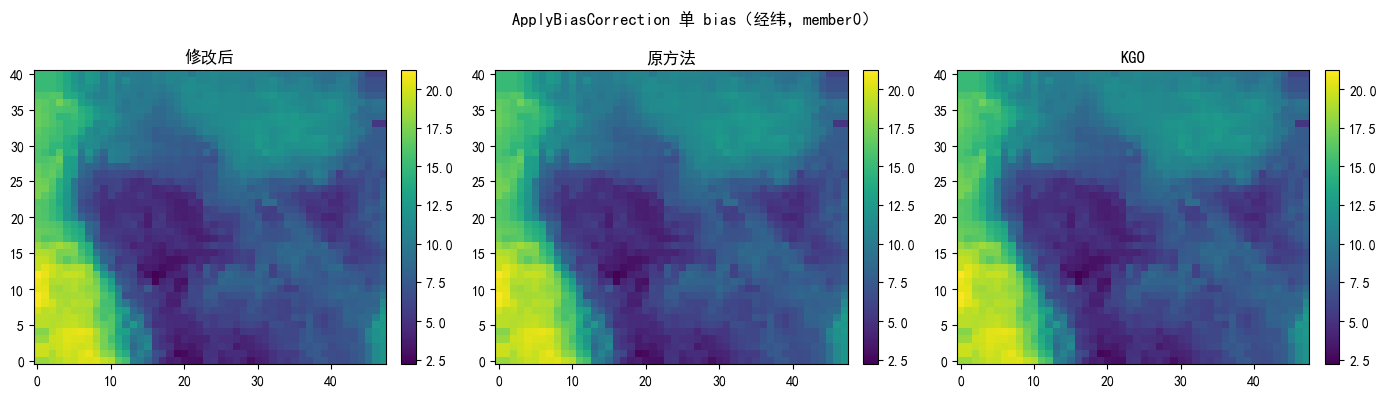

In [11]:
# --- 路径定义 ---
APPLY_DIR = DATA_DIR / "apply-bias-correction"
APPLY_FCST_NAME = "20220814T0300Z-PT0003H00M-wind_speed_at_10m.nc"
APPLY_SINGLE = APPLY_DIR / "single_bias_file"
bias_name = "20220813T0300Z-PT0003H00M-wind_speed_at_10m.nc"

APPLY_LATLON_FCST = APPLY_DIR / "latlon" / APPLY_FCST_NAME              # 经纬 Cube
APPLY_LATLON_MEB_FCST = APPLY_DIR / "latlon" / "cli_input" / APPLY_FCST_NAME  # 经纬 meb
bias_ll = APPLY_SINGLE / "bias_data" / "latlon" / bias_name
bias_ll_meb = APPLY_SINGLE / "bias_data" / "latlon" / "cli_input" / bias_name
kgo_proj = APPLY_SINGLE / "kgo.nc"
require_files(
    [APPLY_LATLON_FCST, APPLY_LATLON_MEB_FCST, bias_ll, bias_ll_meb, kgo_proj],
    "经纬单偏差订正用例",
)

# --- 修改后方法 ---
mod_corr_ll = ApplyBiasCorrection(lower_bound=0.0).process(
    meb.checkout_griddata(meb.read_griddata_from_nc(str(APPLY_LATLON_MEB_FCST)), valid_val=(-np.inf, np.inf, np.nan)),
    meb.checkout_griddata(meb.read_griddata_from_nc(str(bias_ll_meb)), valid_val=(-np.inf, np.inf, np.nan)),
)
# --- 原方法 ---
orig_corr_ll = OrigApplyBiasCorrection(lower_bound=0.0).process(
    iris.load_cube(str(APPLY_LATLON_FCST)), iris.load_cube(str(bias_ll))
)
# KGO：由 preprocess 将投影 KGO 重网格到经纬后写出
kgo_ll = iris.load_cube(str(kgo_proj.parent / "latlon" / "kgo.nc"))

# --- 对比（经纬输入有插值误差，容差放宽到 1e-2）---
compare_fields(mod_corr_ll, orig_corr_ll, "ApplyBiasCorrection 单bias 经纬 修改后-原方法")
compare_fields(mod_corr_ll, kgo_ll, "ApplyBiasCorrection 单bias 经纬 修改后-KGO(重网格)", atol=1e-2)
compare_fields(orig_corr_ll, kgo_ll, "ApplyBiasCorrection 单bias 经纬 原方法-KGO(重网格)", atol=1e-2)
plot_triplet(
    mod_corr_ll, orig_corr_ll, kgo_ll, "ApplyBiasCorrection 单 bias（经纬，member0）", member_index=0
)

## 5. CLI 端到端验证

验证完整业务链路：`process()` 读取 → 插件计算 → **写出 `.nc`** → 再读入 → 与 KGO 对比。

- 修改后 CLI 使用 `xarray.to_netcdf()` 直写，无精度损失
- 原方法 CLI 为预生成的 `orig_cli_*.nc`（事先用 IMPROVER 命令写出一次）
- 对照：修改后 CLI ≈ 原方法 CLI ≈ KGO

### `cal_calculate_forecast_bias`

| 角色 | 路径 |
|------|------|
| 修改后 CLI | `calculate-forecast-bias/cli_output/mig_calculate_forecast_bias.nc` |
| 原方法 CLI | `calculate-forecast-bias/cli_output/orig_cli_calculate_forecast_bias.nc` |
| KGO | `calculate-forecast-bias/multiple_frt/kgo.nc` |


[CLI 算偏差 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CLI 算偏差 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CLI 算偏差 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


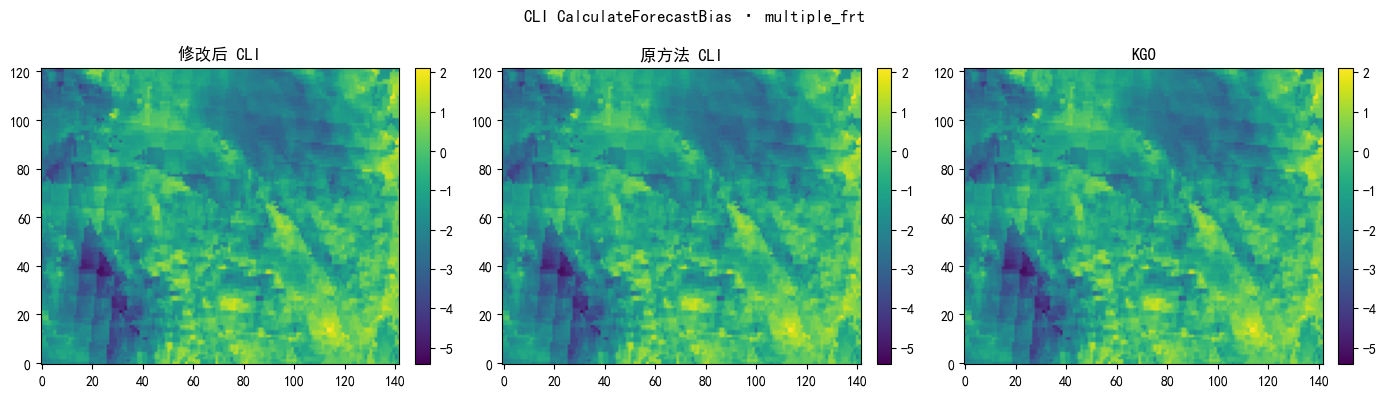

In [12]:
# --- 路径定义 ---
CALC_DIR = DATA_DIR / "calculate-forecast-bias"
CALC_MEB = CALC_DIR / "inputs" / "cli_input"
MULTI_DAYS = ("20220811", "20220812", "20220813")

from simple_bias_correction.cli.cal_calculate_forecast_bias import (
    process as calc_bias_cli_process,
)

# --- 收集输入文件 ---
fcst_meb = sorted(
    p
    for p in CALC_MEB.glob("*PT0003H00M*.nc")
    if any(d in p.name for d in MULTI_DAYS)
)
truth_meb = sorted(
    p
    for p in CALC_MEB.glob("*PT0000H00M*.nc")
    if any(d in p.name for d in MULTI_DAYS)
)

mig_out = CALC_DIR / "cli_output" / "mig_calculate_forecast_bias.nc"
orig_out = CALC_DIR / "cli_output" / "orig_cli_calculate_forecast_bias.nc"
kgo_path = CALC_DIR / "multiple_frt" / "kgo.nc"
require_files(list(fcst_meb) + list(truth_meb) + [orig_out, kgo_path], "CLI CalculateForecastBias")

# --- 修改后 CLI：读入 → 计算 → 写出 → 再读回，模拟完整业务链路 ---
if mig_out.exists():
    mig_out.unlink()
calc_bias_cli_process(fcst_meb, truth_meb, output_path=mig_out)

mig_calc = meb.checkout_griddata(meb.read_griddata_from_nc(str(mig_out)), valid_val=(-np.inf, np.inf, np.nan))
orig_calc = iris.load_cube(str(orig_out))
kgo_calc = iris.load_cube(str(kgo_path))

# --- 对比（xarray 直写无精度损失，使用默认容差）---
compare_fields(mig_calc, orig_calc, "CLI 算偏差 修改后-原方法")
compare_fields(mig_calc, kgo_calc, "CLI 算偏差 修改后-KGO")
compare_fields(orig_calc, kgo_calc, "CLI 算偏差 原方法-KGO")
plot_triplet(
    mig_calc, orig_calc, kgo_calc, "CLI CalculateForecastBias · multiple_frt",
    labels=("修改后 CLI", "原方法 CLI", "KGO"),
)

### `prb_bias_correction`

| 角色 | 路径 |
|------|------|
| 修改后 CLI | `apply-bias-correction/single_bias_file/cli_output/mig_apply_bias_correction.nc` |
| 原方法 CLI | `apply-bias-correction/single_bias_file/cli_output/orig_cli_apply_bias_correction.nc` |
| KGO | `apply-bias-correction/single_bias_file/kgo.nc` |


[CLI 订正 修改后-原方法] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CLI 订正 修改后-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0
[CLI 订正 原方法-KGO] allclose=True, mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000, nan_mismatch=0


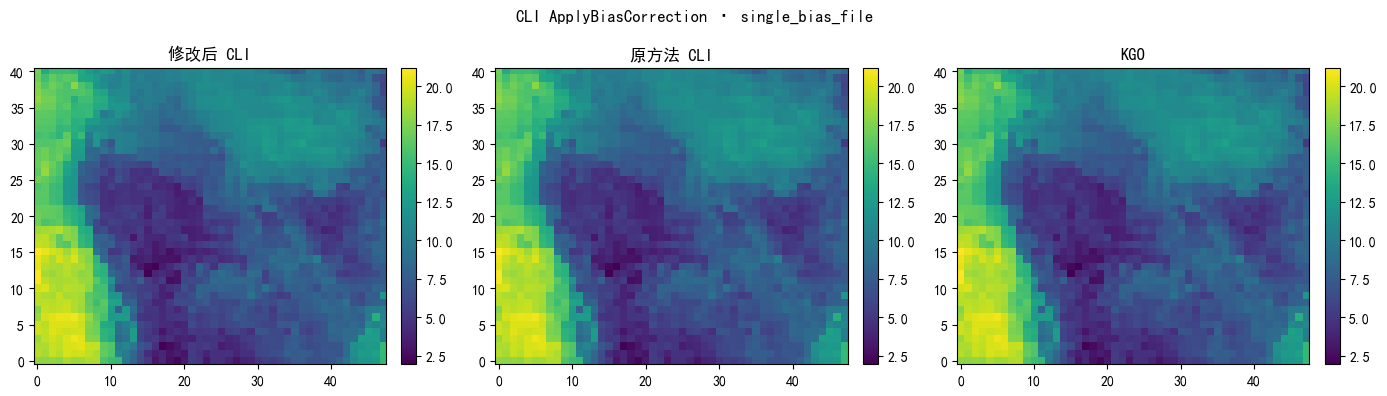

In [13]:
# --- 路径定义 ---
APPLY_DIR = DATA_DIR / "apply-bias-correction"
scenario = APPLY_DIR / "single_bias_file"

from simple_bias_correction.cli.prb_bias_correction import (
    process as apply_bias_cli_process,
)

# --- 收集输入文件 ---
mig_out = scenario / "cli_output" / "mig_apply_bias_correction.nc"
orig_out = scenario / "cli_output" / "orig_cli_apply_bias_correction.nc"
kgo_path = scenario / "kgo.nc"
forecast_meb = APPLY_DIR / "cli_input" / "20220814T0300Z-PT0003H00M-wind_speed_at_10m.nc"
bias_meb = scenario / "bias_data" / "cli_input" / "20220813T0300Z-PT0003H00M-wind_speed_at_10m.nc"
require_files([forecast_meb, bias_meb, orig_out, kgo_path], "CLI ApplyBiasCorrection")

# --- 修改后 CLI：读入 → 计算 → 写出 → 再读回 ---
if mig_out.exists():
    mig_out.unlink()
apply_bias_cli_process(
    forecast_meb, [bias_meb], lower_bound=0.0, output_path=mig_out
)

mig_apply = meb.checkout_griddata(meb.read_griddata_from_nc(str(mig_out)), valid_val=(-np.inf, np.inf, np.nan))
orig_apply = iris.load_cube(str(orig_out))
kgo_apply = iris.load_cube(str(kgo_path))

# --- 对比 ---
compare_fields(mig_apply, orig_apply, "CLI 订正 修改后-原方法")
compare_fields(mig_apply, kgo_apply, "CLI 订正 修改后-KGO")
compare_fields(orig_apply, kgo_apply, "CLI 订正 原方法-KGO")
plot_triplet(
    mig_apply, orig_apply, kgo_apply, "CLI ApplyBiasCorrection · single_bias_file",
    member_index=0, labels=("修改后 CLI", "原方法 CLI", "KGO"),
)

## 6. 小结

| 插件 | 投影输入（内存） | 投影输入（CLI 写出-读回） | 经纬输入 |
|------|:---:|:---:|:---:|
| `CalculateForecastBias` | ✅ 零差异 | ✅ 零差异 | ✅（插值容差内） |
| `ApplyBiasCorrection` | ✅ 零差异 | ✅ 零差异 | ✅（插值容差内） |

**关键结论**：迁移后的插件方法在相同输入下与 IMPROVER 原实现数值完全一致（float32 位对位相同）。